# Análisis de Correlaciones - Commodities y Predictores

**Objetivo:** Analizar relaciones entre commodities y predictores macroeconómicos

Este notebook:
- Carga datos procesados en formato wide
- Calcula matrices de correlación
- Identifica relaciones fuertes
- Visualiza heatmaps

In [1]:
# Setup
import sys
from pathlib import Path

# Agregar directorio raíz del proyecto al PYTHONPATH
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importar módulos del proyecto
from src.data import process
from src.config import PROCESSED_DIR, FIGURES_DIR
from src.visualization import configurar_estilo_grafico, formatear_ejes

# Configurar estilo visual institucional
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")
%matplotlib inline

# Configurar display de pandas
pd.options.display.max_columns = 50

## 1. Cargar Datos Procesados

In [2]:
# Verificar si existe el dataset procesado
processed_file = PROCESSED_DIR / 'commodities_base_daily.csv'

if processed_file.exists():
    print(f"✓ Cargando datos procesados desde {processed_file}")
    df = pd.read_csv(processed_file, parse_dates=['date'])
else:
    print("⚠ Dataset procesado no encontrado. Ejecutando pipeline de procesamiento...")
    df = process.main()

print(f"\n📊 Dimensiones: {df.shape}")
print(f"📅 Período: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

✓ Cargando datos procesados desde C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\commodities_base_daily.csv

📊 Dimensiones: (6537, 250)
📅 Período: 2000-01-03 → 2025-10-27

📊 Dimensiones: (6537, 250)
📅 Período: 2000-01-03 → 2025-10-27


,date,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybeans,Sugar,Wheat,DXY,Energy_Index,...,Oat_return7,Palladium_return1,Palladium_return7,Platinum_return1,Platinum_return7,RBOB_Gasoline_return1,RBOB_Gasoline_return7,Silver_return1,Silver_return7,Soybeans_return1,Soybeans_return7,Sugar_return1,Sugar_return7,Wheat_return1,Wheat_return7,DXY_return1,DXY_return7,Energy_Index_return1,Energy_Index_return7,SP500_return1,SP500_return7,Treasury_10Y_return1,Treasury_10Y_return7,VIX_return1,VIX_return7
0,2000-01-03,NaN,830.0,116.500000,NaN,NaN,51.070000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.220001,206.580002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,836.0,116.250000,NaN,NaN,50.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00,441.899994,429.700012,NaN,NaN,NaN,NaN,NaN,100.410004,202.380005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.189585,NaN,-2.033109,NaN,-3.834467,NaN,-0.962122,NaN,11.565474,NaN
2,2000-01-05,NaN,831.0,118.599998,NaN,NaN,51.560001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.75,438.100006,419.899994,NaN,NaN,NaN,NaN,NaN,100.379997,208.559998,...,NaN,-0.859920,NaN,-2.280665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.029884,NaN,3.053658,NaN,0.192218,NaN,1.757900,NaN,-2.221401,NaN
3,2000-01-06,NaN,841.0,116.849998,NaN,NaN,52.080002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00,435.299988,412.000000,NaN,NaN,NaN,NaN,NaN,100.650002,218.139999,...,NaN,-0.639128,NaN,-1.881399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.268982,NaN,4.593403,NaN,0.095568,NaN,-0.757693,NaN,-2.574783,NaN
4,2000-01-07,NaN,853.0,114.150002,NaN,NaN,53.959999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.25,443.899994,414.000000,NaN,NaN,NaN,NaN,NaN,100.800003,220.850006,...,NaN,1.975650,NaN,0.485437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149033,NaN,1.242325,NaN,2.709040,NaN,-0.687122,NaN,-15.584921,NaN


## 2. Seleccionar Columnas de Precios

Filtramos solo las columnas de precios originales (sin lags, rolling, returns)

In [3]:
# Identificar columnas de precios base (sin features engineered)
exclude_patterns = ['lag', 'ma', 'std', 'return', 'year', 'month', 'quarter', 'day', 'week']

price_columns = [col for col in df.columns 
                 if col not in ['date'] and 
                 not any(pattern in col.lower() for pattern in exclude_patterns)]

print(f"📊 Columnas de precios identificadas: {len(price_columns)}")
print(f"\nColumnas: {price_columns[:10]}...")  # Mostrar primeras 10

# Crear subset solo con precios
df_prices = df[price_columns].copy()

📊 Columnas de precios identificadas: 27

Columnas: ['Brent_Crude', 'Cocoa', 'Coffee', 'Copper', 'Corn', 'Cotton', 'Crude_Oil', 'Feeder_Cattle', 'Gold', 'Heating_Oil']...


## 3. Matriz de Correlación Completa

📊 Matriz de correlación: (27, 27)


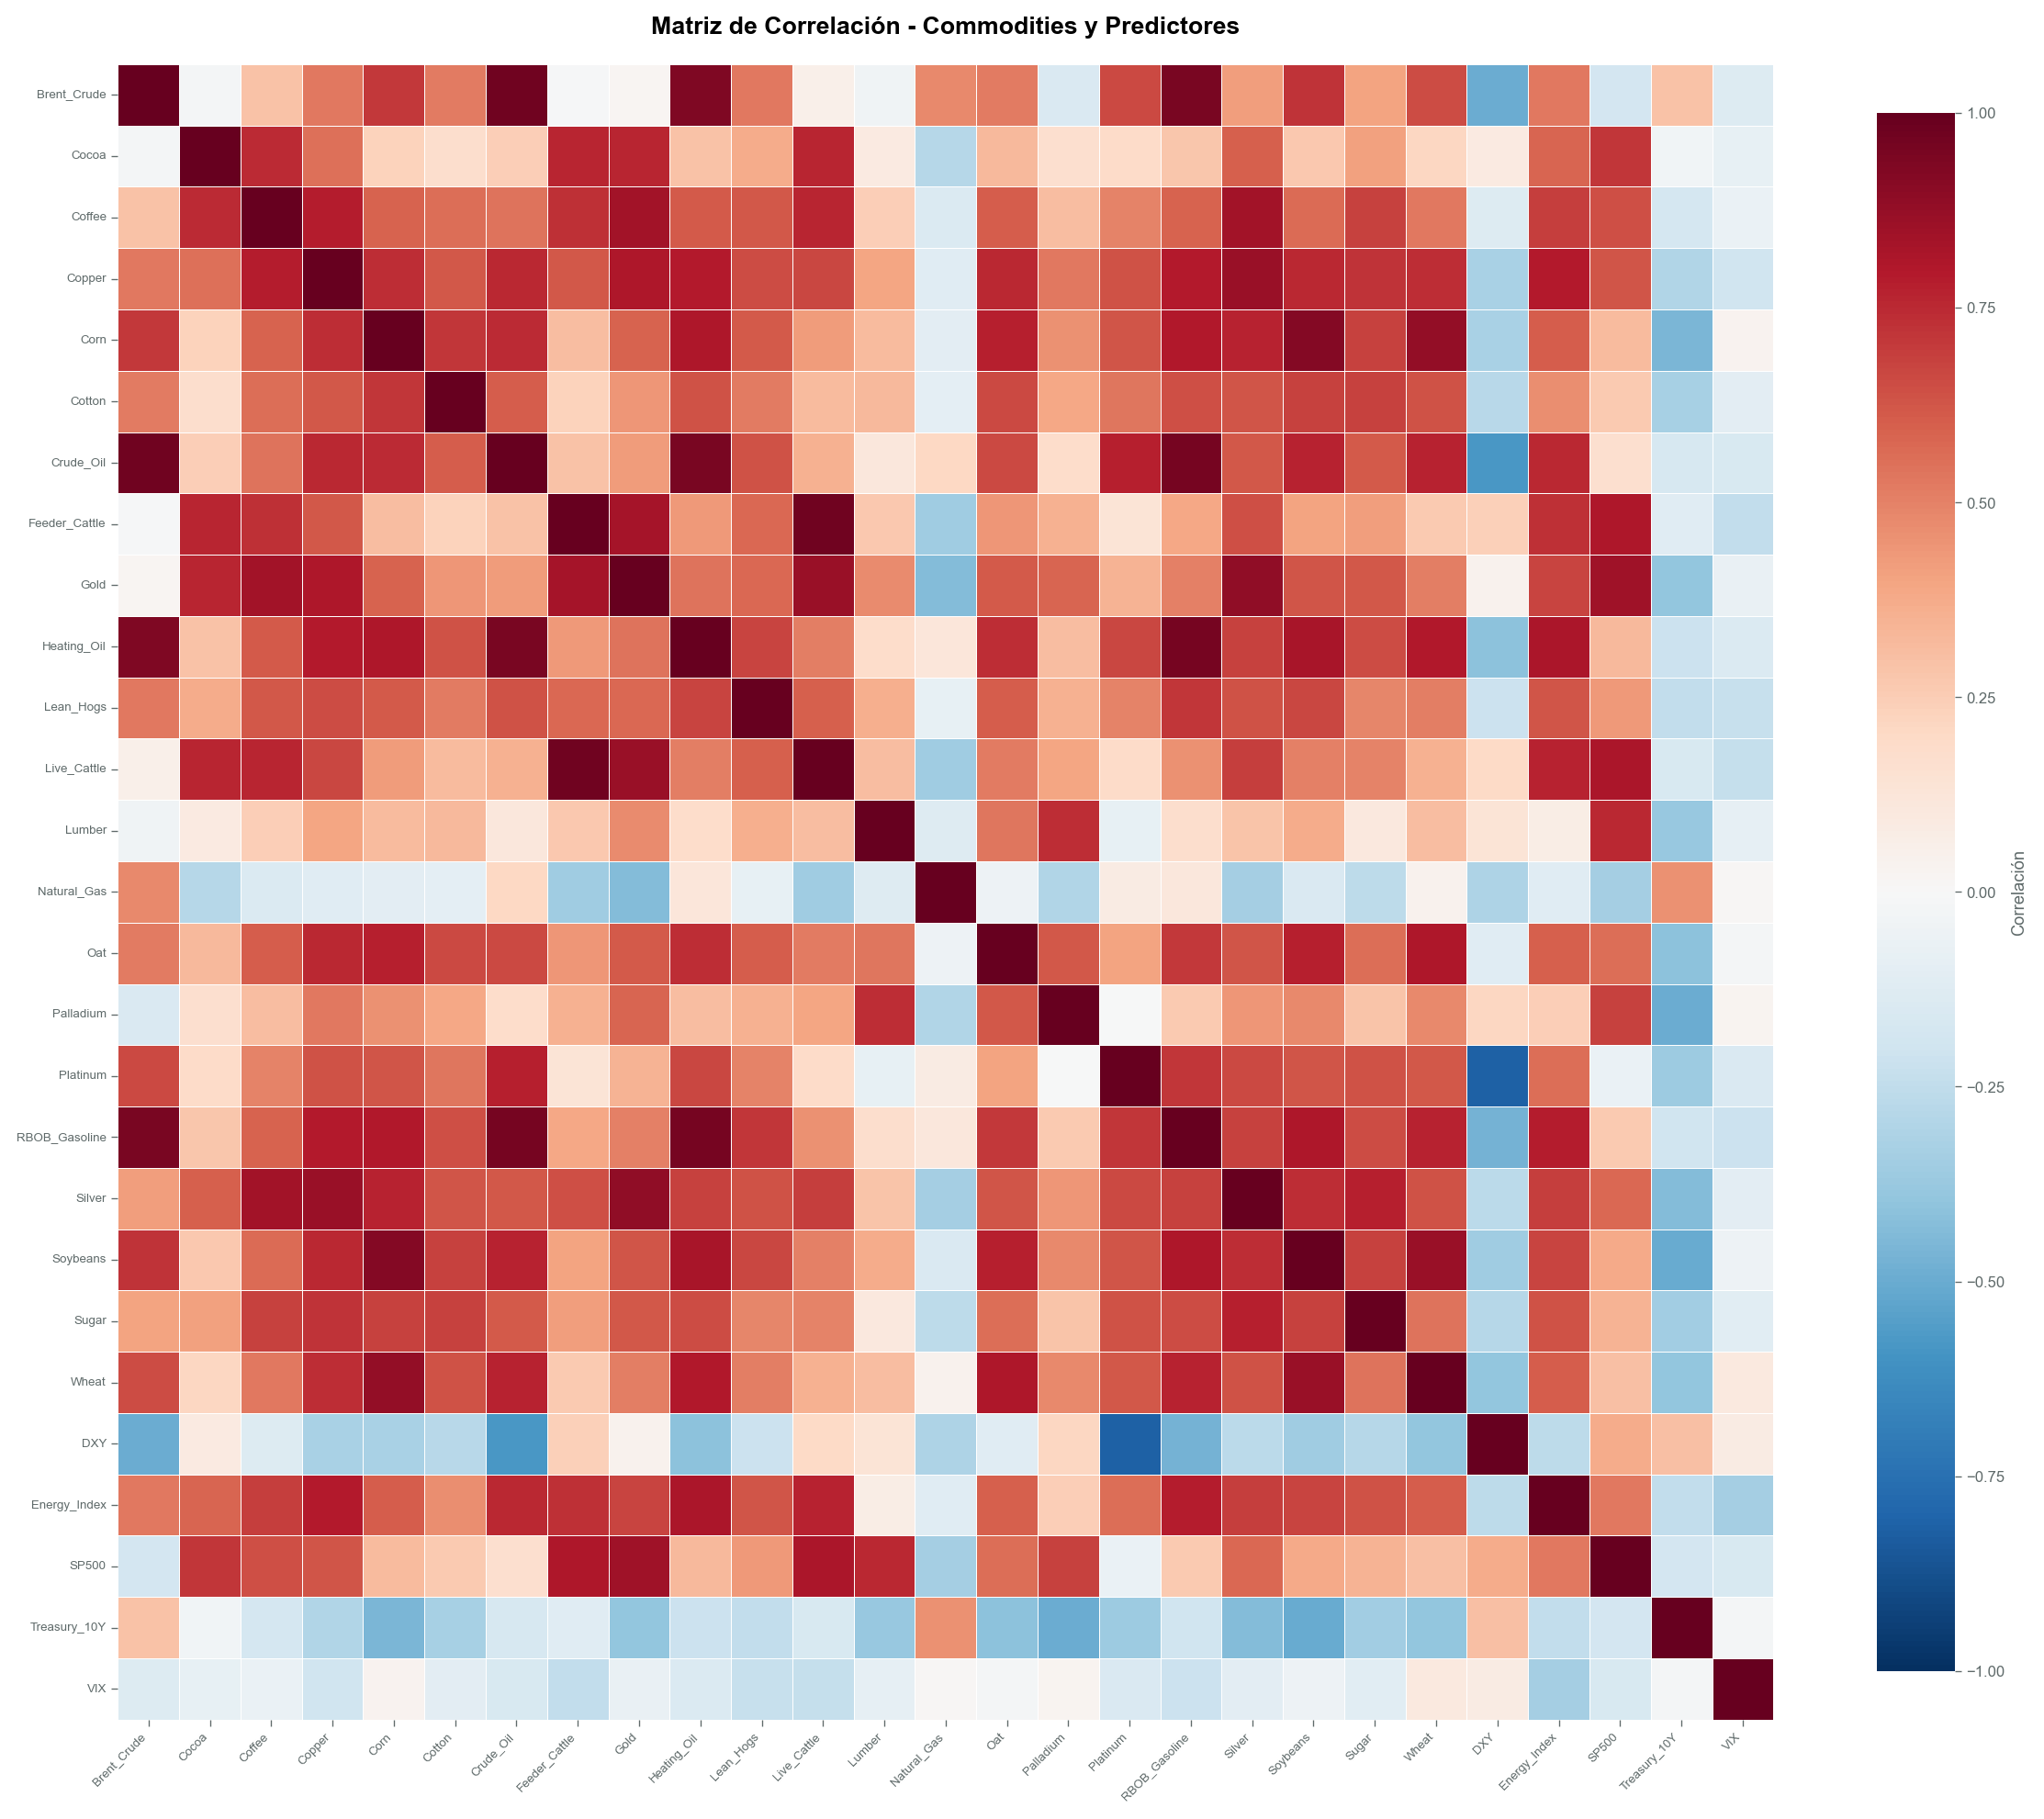

In [4]:
# Calcular matriz de correlación
corr_matrix = df_prices.corr()

print(f"📊 Matriz de correlación: {corr_matrix.shape}")

# Heatmap completo con colores UBA
fig, ax = plt.subplots(figsize=(20, 18))

sns.heatmap(corr_matrix, 
            cmap='RdBu_r', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            annot=False,
            fmt='.2f',
            ax=ax)

ax.set_title('Matriz de Correlación - Commodities y Predictores', 
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlacion_completa.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Correlaciones Más Fuertes

Identificar pares con correlación |r| > 0.7

In [5]:
# Extraer correlaciones fuertes
def get_strong_correlations(corr_matrix, threshold=0.7):
    """
    Encuentra pares con correlación absoluta mayor al threshold
    """
    # Crear máscara para triángulo superior (evitar duplicados)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    # Extraer correlaciones
    strong_corr = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                strong_corr.append({
                    'Variable 1': corr_matrix.index[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlación': corr_matrix.iloc[i, j]
                })
    
    return pd.DataFrame(strong_corr).sort_values('Correlación', key=abs, ascending=False)

strong_corr_df = get_strong_correlations(corr_matrix, threshold=0.7)

print(f"\n🔍 Pares con correlación |r| >= 0.7: {len(strong_corr_df)}\n")
strong_corr_df.head(20)


🔍 Pares con correlación |r| >= 0.7: 68



,Variable 1,Variable 2,Correlación
41,Feeder_Cattle,Live_Cattle,0.976314
1,Brent_Crude,Crude_Oil,0.974720
36,Crude_Oil,RBOB_Gasoline,0.959221
48,Heating_Oil,RBOB_Gasoline,0.957982
34,Crude_Oil,Heating_Oil,0.951597
3,Brent_Crude,RBOB_Gasoline,0.949878
2,Brent_Crude,Heating_Oil,0.929741
32,Corn,Soybeans,0.920312
45,Gold,Silver,0.883431
33,Corn,Wheat,0.877021


## 5. Correlaciones con Predictores

Analizar específicamente cómo cada predictor se correlaciona con commodities

📊 Predictores disponibles: ['VIX', 'DXY', 'SP500', 'Treasury_10Y', 'Energy_Index']
📊 Commodities: 22


Predictor: VIX

Top 10 correlaciones más fuertes con VIX:
Feeder_Cattle   -0.249645
Live_Cattle     -0.241242
Lean_Hogs       -0.233476
RBOB_Gasoline   -0.211042
Copper          -0.198086
Crude_Oil       -0.159284
Platinum        -0.150720
Heating_Oil     -0.143078
Brent_Crude     -0.134159
Sugar           -0.111441
Name: VIX, dtype: float64


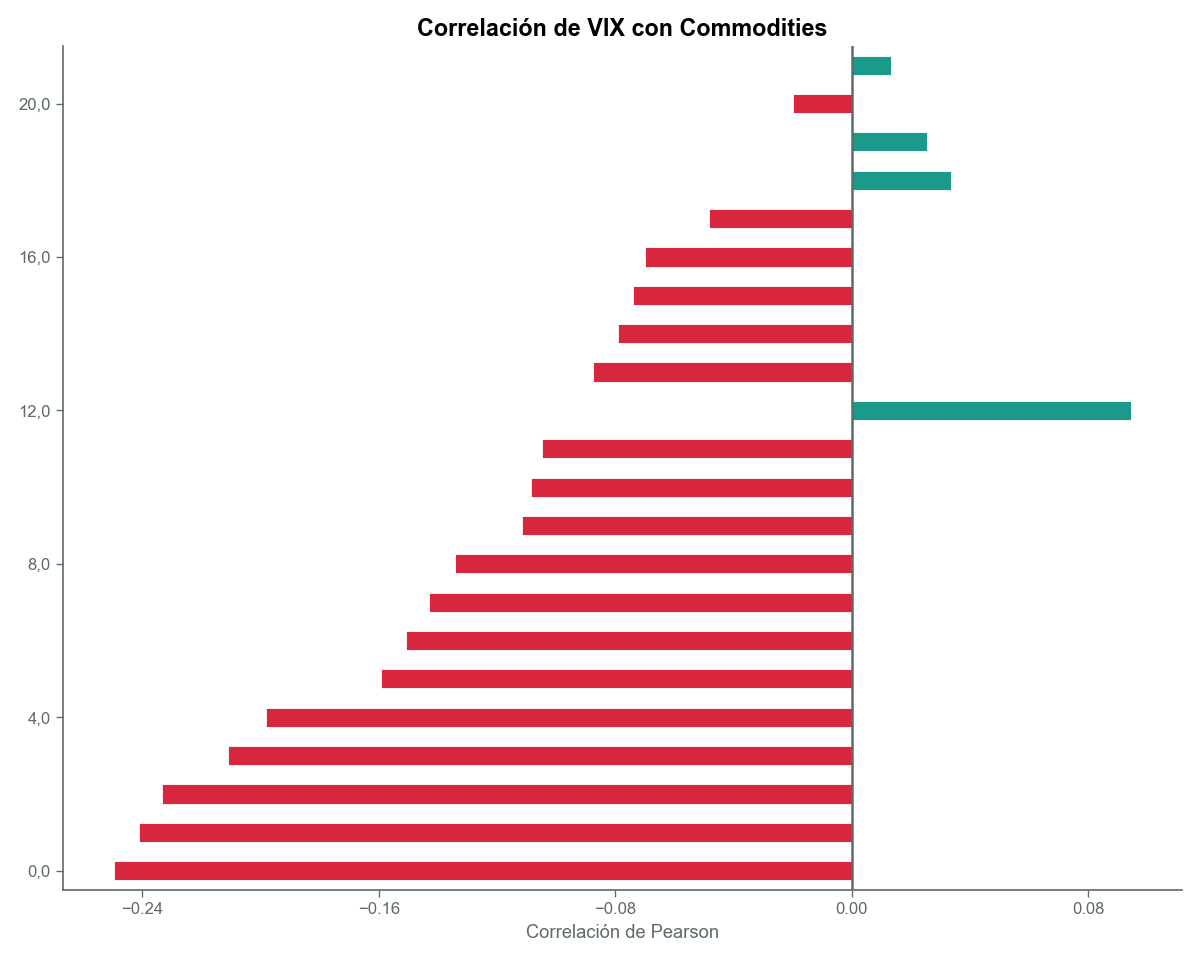


Predictor: DXY

Top 10 correlaciones más fuertes con DXY:
Platinum        -0.814668
Crude_Oil       -0.580897
Brent_Crude     -0.494616
RBOB_Gasoline   -0.470041
Heating_Oil     -0.410268
Wheat           -0.394664
Soybeans        -0.353173
Corn            -0.325264
Copper          -0.322396
Natural_Gas     -0.306536
Name: DXY, dtype: float64


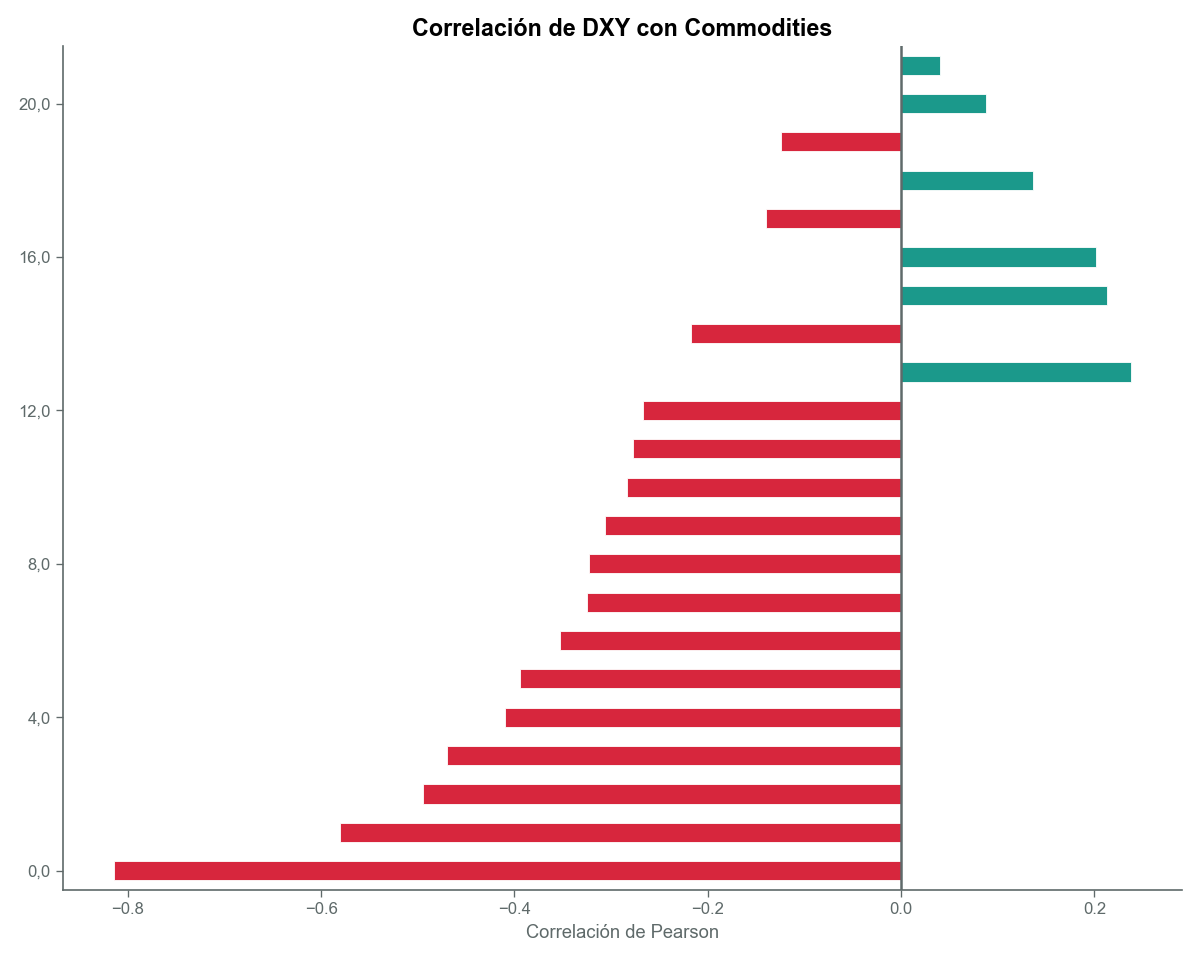


Predictor: SP500

Top 10 correlaciones más fuertes con SP500:
Gold             0.846546
Live_Cattle      0.817136
Feeder_Cattle    0.808953
Lumber           0.750723
Cocoa            0.715720
Palladium        0.684894
Coffee           0.645204
Copper           0.626248
Silver           0.571528
Oat              0.555414
Name: SP500, dtype: float64


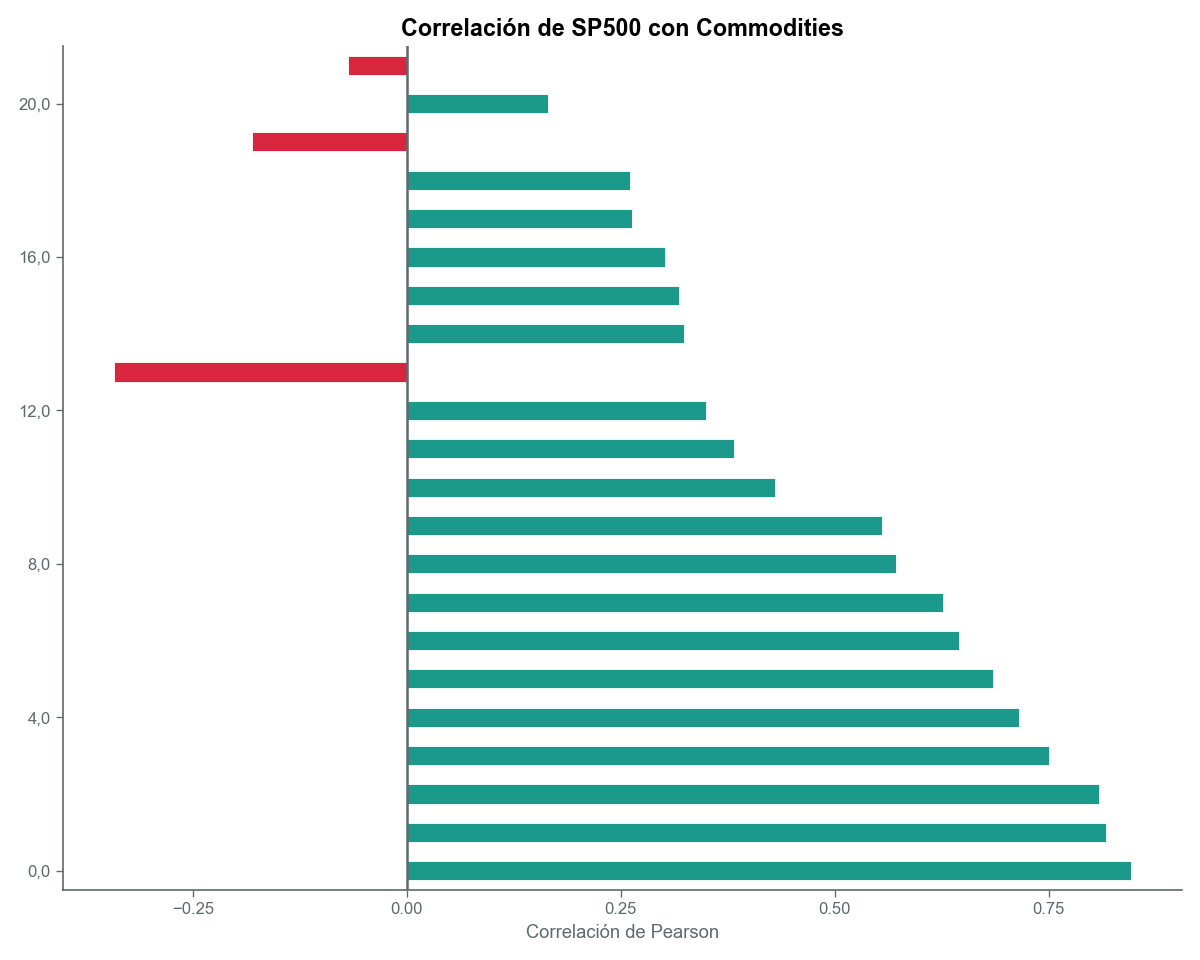


Predictor: Treasury_10Y

Top 10 correlaciones más fuertes con Treasury_10Y:
Soybeans      -0.503439
Palladium     -0.494872
Natural_Gas    0.459710
Corn          -0.453856
Silver        -0.432917
Oat           -0.408455
Wheat         -0.393407
Gold          -0.392309
Lumber        -0.377073
Platinum      -0.362071
Name: Treasury_10Y, dtype: float64


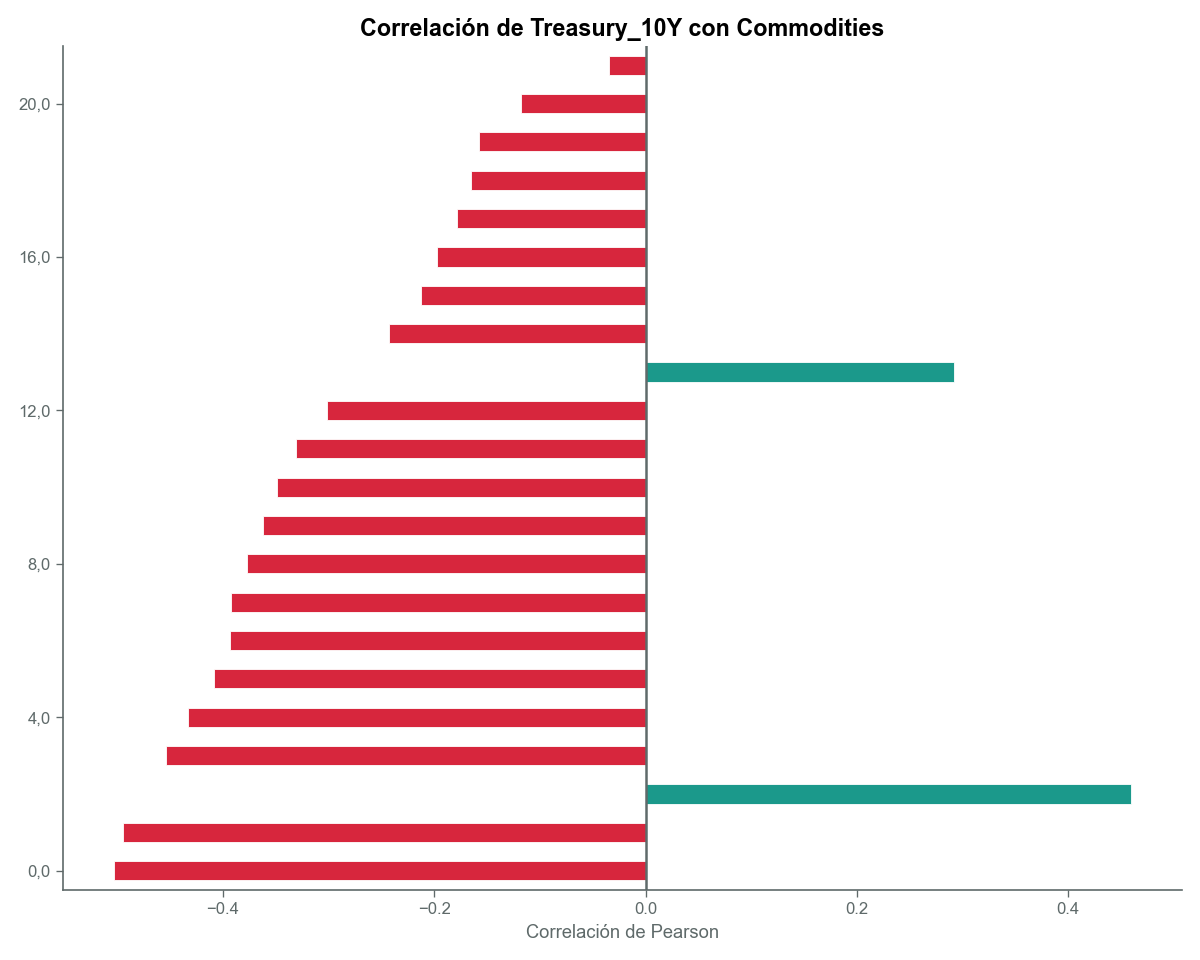


Predictor: Energy_Index

Top 10 correlaciones más fuertes con Energy_Index:
Heating_Oil      0.816420
Copper           0.790179
RBOB_Gasoline    0.783163
Live_Cattle      0.771879
Crude_Oil        0.750657
Feeder_Cattle    0.729825
Coffee           0.694791
Silver           0.689694
Gold             0.679288
Soybeans         0.676652
Name: Energy_Index, dtype: float64


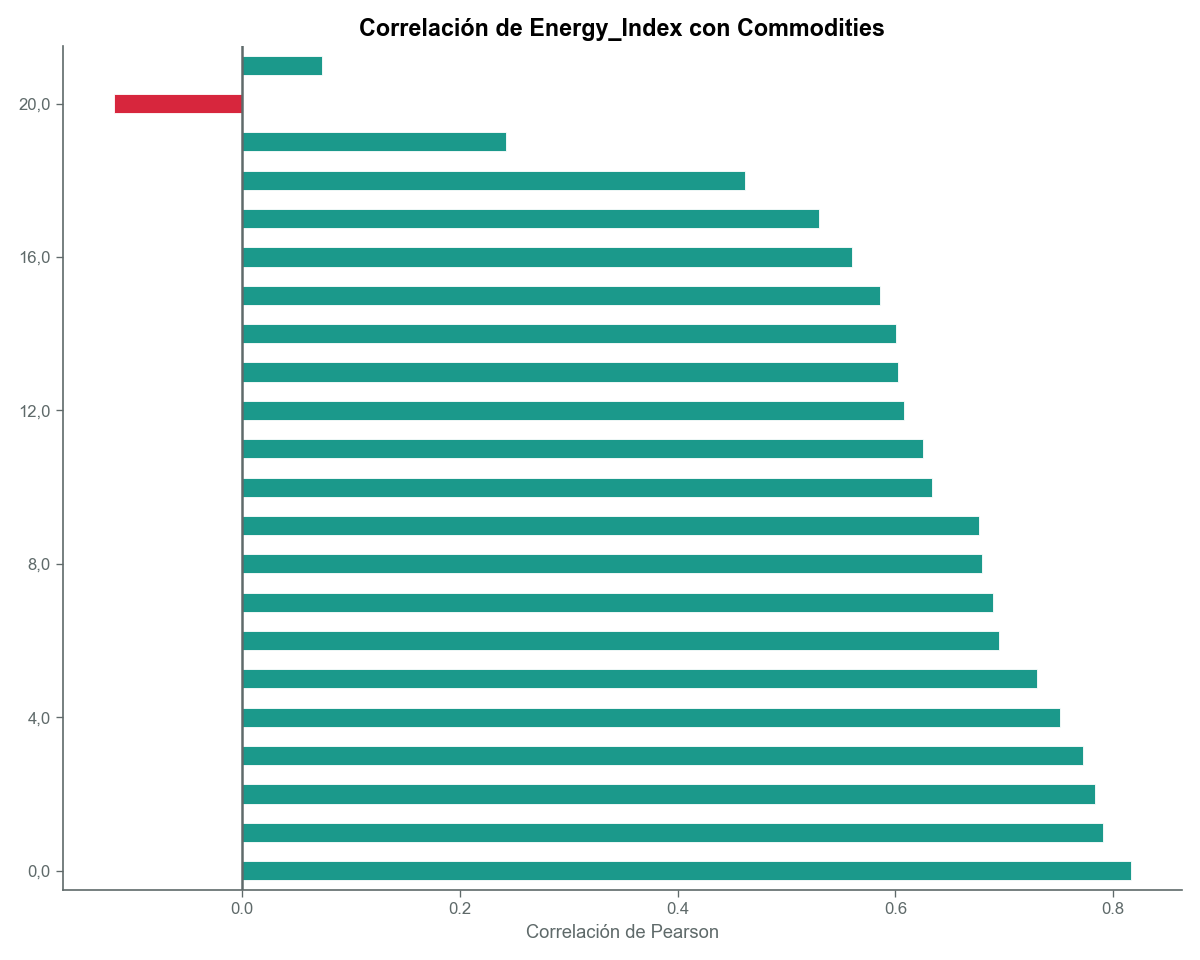

In [6]:
# Identificar predictores (asumiendo que tienen nombres conocidos)
predictor_names = ['VIX', 'DXY', 'SP500', 'Treasury_10Y', 'Energy_Index']

# Filtrar predictores que existan en el dataset
available_predictors = [p for p in predictor_names if p in df_prices.columns]

if available_predictors:
    # Columnas de commodities (excluir predictores)
    commodity_cols = [col for col in price_columns if col not in available_predictors]
    
    print(f"📊 Predictores disponibles: {available_predictors}")
    print(f"📊 Commodities: {len(commodity_cols)}\n")
    
    # Correlaciones de cada predictor con commodities
    for predictor in available_predictors:
        print(f"\n{'='*60}")
        print(f"Predictor: {predictor}")
        print(f"{'='*60}")
        
        pred_corr = corr_matrix.loc[commodity_cols, predictor].sort_values(key=abs, ascending=False)
        
        print(f"\nTop 10 correlaciones más fuertes con {predictor}:")
        print(pred_corr.head(10))
        
        # Visualización con colores institucionales
        fig, ax = plt.subplots(figsize=(10, max(8, len(commodity_cols)*0.3)))
        
        colors = [COLORES['rojo'] if x < 0 else COLORES['verde_eco'] for x in pred_corr.values]
        pred_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
        
        ax.set_title(f'Correlación de {predictor} con Commodities', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Correlación de Pearson')
        ax.axvline(x=0, color=COLORES['gris_oscuro'], linewidth=1.5)
        formatear_ejes(ax, x_as=None)
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'correlacion_{predictor.lower()}_commodities.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("⚠ No se encontraron predictores en el dataset")

## 6. Clustermap - Agrupación Jerárquica

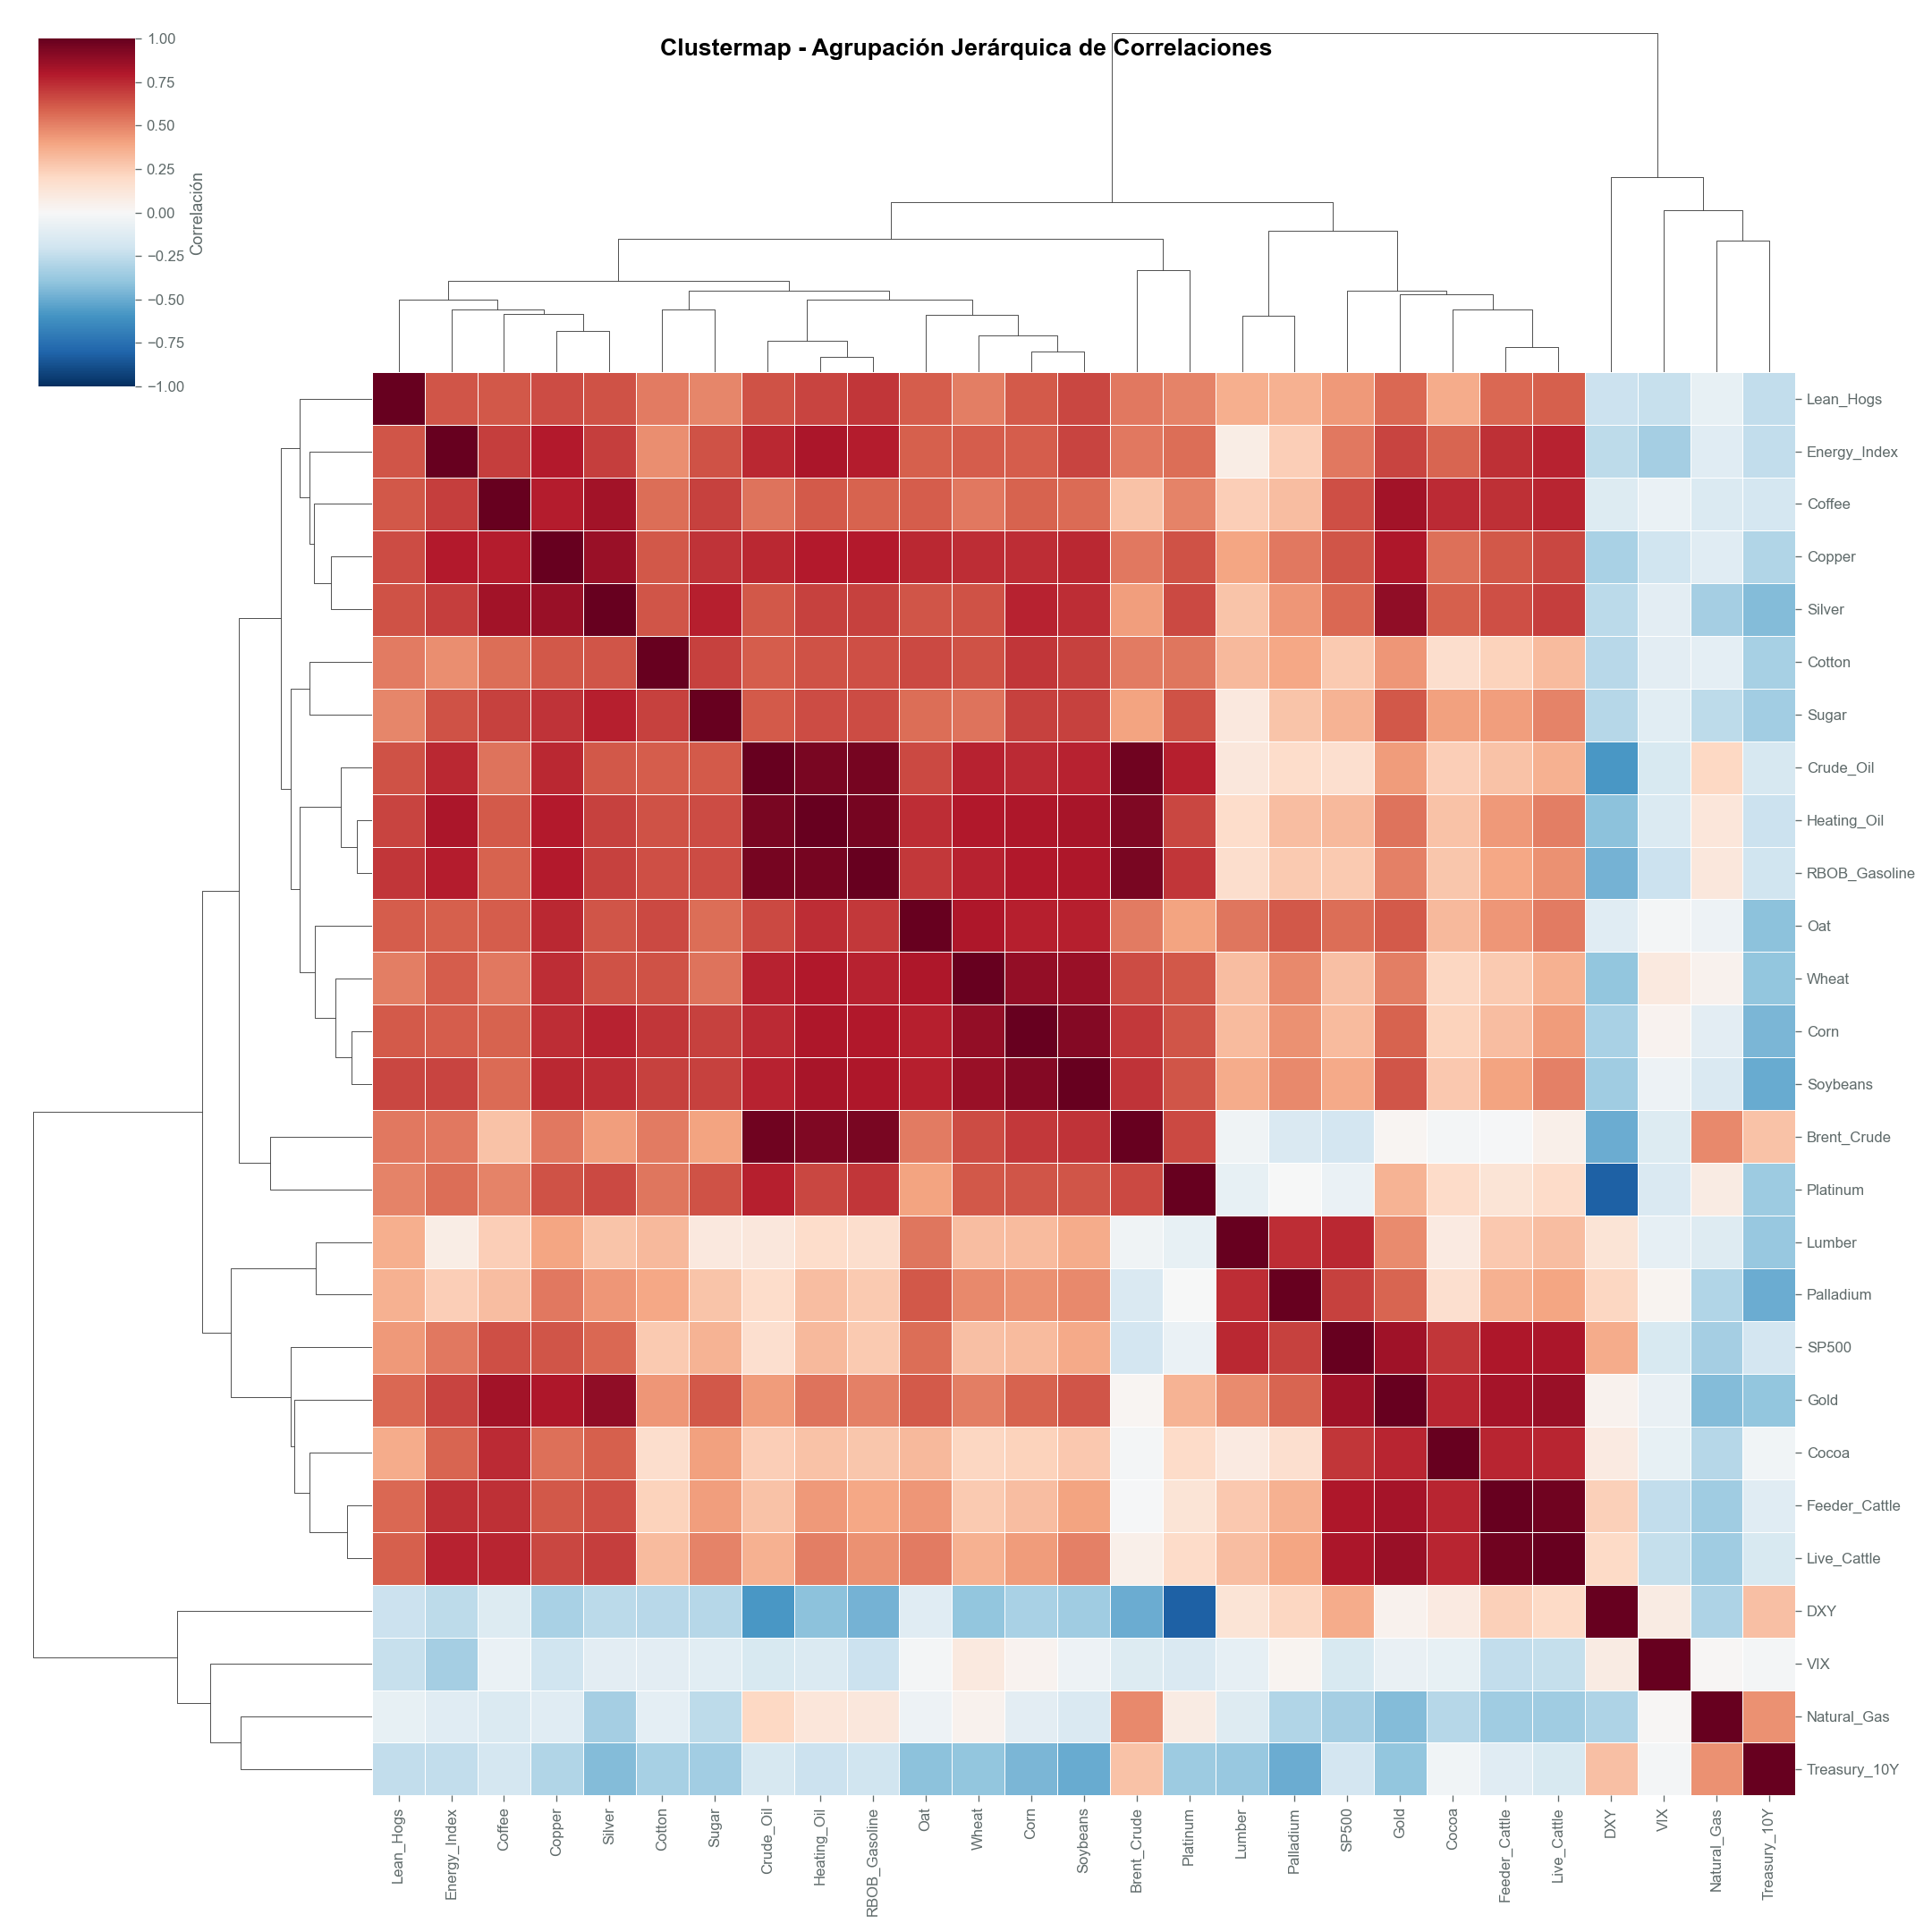

In [7]:
# Clustermap para identificar grupos de commodities con comportamiento similar
g = sns.clustermap(corr_matrix, 
                   cmap='RdBu_r', 
                   center=0,
                   vmin=-1, vmax=1,
                   figsize=(18, 18),
                   linewidths=0.5,
                   cbar_kws={'label': 'Correlación'},
                   annot=False,
                   fmt='.2f')

g.fig.suptitle('Clustermap - Agrupación Jerárquica de Correlaciones', 
               fontsize=16, fontweight='bold', y=0.98)

plt.savefig(FIGURES_DIR / 'correlacion_clustermap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Exportar Resultados

In [8]:
# Guardar matriz de correlación
corr_matrix.to_csv(PROCESSED_DIR / 'correlation_matrix.csv')
print(f"✓ Matriz de correlación guardada: {PROCESSED_DIR / 'correlation_matrix.csv'}")

# Guardar correlaciones fuertes
strong_corr_df.to_csv(PROCESSED_DIR / 'strong_correlations.csv', index=False)
print(f"✓ Correlaciones fuertes guardadas: {PROCESSED_DIR / 'strong_correlations.csv'}")

✓ Matriz de correlación guardada: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\correlation_matrix.csv
✓ Correlaciones fuertes guardadas: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\strong_correlations.csv


## 8. Conclusiones

**Insights clave del análisis de correlaciones:**

1. **Commodities altamente correlacionados:** Identificar grupos (ej: metales preciosos, energía)
2. **Relación con predictores:** Evaluar poder predictivo de VIX, DXY, etc.
3. **Diversificación:** Commodities con baja correlación son buenos para portfolios
4. **Clusters:** Grupos jerárquicos revelan patrones de comportamiento conjunto

**Próximos análisis:**
- Correlaciones móviles en el tiempo
- Análisis de cointegración
- Modelos de predicción multivariados